In [1]:
import h5py
import numpy as np
from scipy.io import loadmat
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from scipy.ndimage import gaussian_filter1d
from joblib import Parallel, delayed

In [29]:
def downsample_mean(X, factor):
    n_trials, time_len, n_channels, n_sources = X.shape
    cut_len = (time_len // factor) * factor
    X = X[:, :cut_len, :, :]
    print(X.shape)
    X = X.reshape(n_trials, cut_len // factor, factor, n_channels, n_sources)
    print(X.shape)
    return X.mean(axis=2) 
      
def extract_selected_indices(
    X,
    MUA,
    y,
    sessions,
    groups,
    position_indices,
    selected_within_group,
    condition_label,
    t_min=-0.2,
    t_max=0.6,
    baseline_window=(-0.2, -0.05),
    downsample_factor=None,
):

    subset_label_map = {}

    for pos_label, pos_idx in enumerate(position_indices):
        group = groups[pos_idx]
        selected_labels = [
            group[i] for i in selected_within_group
            if i < len(group)
        ]
        for label in selected_labels:
            subset_label_map[label] = pos_label


    mask = np.isin(y, list(subset_label_map.keys()))

    X_subset = X[mask]
    MUA_subset = MUA[mask]
    y_subset = y[mask]
    session_subset = sessions[mask]

    y_local = np.array([subset_label_map[int(label)] for label in y_subset])
    y_condition = np.full(len(y_local), condition_label)
    MUA_subset = MUA_subset[:, :, :, 3:4]

    # Baseline correction for MUA
    N, T, C, F = MUA_subset.shape

    fs = T / (t_max - t_min)

    b_start, b_end = baseline_window
    b_start_idx = int((b_start - t_min) * fs)
    b_end_idx = int((b_end - t_min) * fs)

    if b_start_idx < 0 or b_end_idx > T:
        raise ValueError("Baseline window outside epoch range")

    baseline = MUA_subset[:, b_start_idx:b_end_idx].mean(axis=1, keepdims=True)
    MUA_subset = MUA_subset - baseline

    #Combine features
    X_combined = np.concatenate([X_subset, MUA_subset], axis=-1)

    if downsample_factor is not None:
        X_combined = downsample_mean(X_combined, downsample_factor)

    return X_combined, y_local, y_condition, session_subset

def compute_scaled_values(X, y, freq_indices, t_start, t_end):
    
    if isinstance(freq_indices, int):
        freq_indices = [freq_indices]

    time_mask = (times >= t_start) & (times <= t_end)
    time_indices = np.where(time_mask)[0]

    mean_per_pos_chan = []
    for pos in positions:
        trials_pos = X[y == pos, :, :, :]  # trials × time × channels × freqs
        
        trials_time_avg = trials_pos[:, time_indices, :, :][:, :, :, freq_indices].mean(axis=1)  # trials × channels × freqs
        trials_freq_avg = trials_time_avg.mean(axis=-1)  #  trials × channels
        mean_channels = trials_freq_avg.mean(axis=0)    # 
        mean_per_pos_chan.append(mean_channels)
    
    mean_per_pos_chan = np.array(mean_per_pos_chan)  # positions × channels
    mean_centered = mean_per_pos_chan - mean_per_pos_chan.mean(axis=0, keepdims=True)

    # [-1, 1]
    min_vals = mean_centered.min(axis=0, keepdims=True)
    max_vals = mean_centered.max(axis=0, keepdims=True)
    mean_scaled = 2 * (mean_centered - min_vals) / (max_vals - min_vals) - 1

    mean_avg = mean_scaled.mean(axis=1)
    std_avg = mean_scaled.std(axis=1)
    return mean_avg, std_avg

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / dof)
    return (x.mean() - y.mean()) / pooled_std

def plot_left_block(fig, outer_spec, results, positions, time_windows):

    left = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer_spec,
        hspace=0.35,
        wspace=0.25
    )

    axes = [fig.add_subplot(left[i, j]) for i in range(2) for j in range(2)]

    for idx, ((t_start, t_end), ax) in enumerate(zip(time_windows, axes[:2])):

        mean_9  = results["mean_9hz"][idx]
        std_9   = results["std_9hz"][idx]
        mean_mua = results["mean_mua"][idx]
        std_mua  = results["std_mua"][idx]

        r      = results["corrs9hz"][idx]
        p_corr = results["pvals_corrected9hz"][idx]
        sig    = results["reject9hz"][idx]

        ax.axvspan(8.0, 14.5, color="lightgray", alpha=0.3)
        for pos in [7.5, 15]:
            ax.axvspan(pos - 0.5, pos + 1,
                       color="gray", alpha=0.3, hatch="///")

        ax.plot(positions, mean_9, color="tab:blue", linewidth=2)
        ax.fill_between(positions,
                        mean_9 - std_9,
                        mean_9 + std_9,
                        color="tab:blue", alpha=0.2)

        ax.plot(positions, mean_mua, color="tab:orange", linewidth=2)
        ax.fill_between(positions,
                        mean_mua - std_mua,
                        mean_mua + std_mua,
                        color="tab:orange", alpha=0.2)

        sig_marker = "*" if sig else "ns"
        #ax.set_title(
        #    f"{t_start:.2f}-{t_end:.2f}s\n"
        #    f"9 Hz r={r:.2f}, p={p_corr:.3f} {sig_marker}",
        #    fontsize=9
        #)

        ax.set_title(
            f"MUA and 9 Hz by positions \n"
            f"{t_start:.2f}-{t_end:.2f}s, r={r:.2f}",
            fontsize=11
        )
        ax.grid(False)

    for idx, ((t_start, t_end), ax) in enumerate(zip(time_windows, axes[2:])):

        mean_25 = results["mean_14hz"][idx]
        std_25  = results["std_14hz"][idx]
        
        mean_mua = results["mean_mua_avg14"][idx]
        std_mua  = results["std_mua"][idx]

        r      = results["corrs14hz"][idx]
        p_corr = results["pvals_corrected14hz"][idx]
        sig    = results["std_mua_avg14"][idx]

        ax.axvspan(8.0, 14.5, color="lightgray", alpha=0.3)
        for pos in [7.5, 15]:
            ax.axvspan(pos - 0.5, pos + 1,
                       color="gray", alpha=0.3, hatch="///")

        ax.plot(positions, mean_25,
                color="tab:blue", linestyle="--", linewidth=2)
        ax.fill_between(positions,
                        mean_25 - std_25,
                        mean_25 + std_25,
                        color="tab:blue", alpha=0.2)

        ax.plot(positions, mean_mua, color="tab:orange", linewidth=2)
        ax.fill_between(positions,
                        mean_mua - std_mua,
                        mean_mua + std_mua,
                        color="tab:orange", alpha=0.2)

        #sig_marker = "*" if sig else "ns"
        #ax.set_title(
        #    f"{t_start:.2f}-{t_end:.2f}s\n"
        #    f"25 Hz r={r:.2f}, p={p_corr:.3f} {sig_marker}",
        #    fontsize=9
        #)
        ax.set_title(
            f"MUA and 25 Hz by positions \n"
            f"{t_start:.2f}-{t_end:.2f}s, r={r:.2f}",
            fontsize=11
        )
        ax.grid(False)


    for ax in axes:
        ax.set_xticklabels([])           #
        ax.tick_params(axis='x', length=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for ax in axes:
        ax.set_xlabel("Figure", fontsize=10)

    axes[0].set_ylabel("Scaled value")
    axes[2].set_ylabel("Scaled value")

    return axes

def compute_freq_results(X, y, freq_idx, time_windows, label, mua_label="mua"):

    means_freq, stds_freq = [], []
    means_mua, stds_mua = [], []
    pvals = []

    for (t_start, t_end) in time_windows:
        mean_freq, std_freq = compute_scaled_values(X, y, freq_indices=[freq_idx], t_start=t_start, t_end=t_end)
        mean_mua,  std_mua  = compute_scaled_values(X, y, freq_indices=[idx_mua],  t_start=t_start, t_end=t_end)

        corr, pval = pearsonr(mean_freq, mean_mua)

        means_freq.append(mean_freq)
        stds_freq.append(std_freq)
        means_mua.append(mean_mua)
        stds_mua.append(std_mua)
        pvals.append(pval)

    reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

    return {
        f"mean_{label}":              means_freq,
        f"std_{label}":               stds_freq,
        f"mean_{mua_label}":          means_mua,
        f"std_{mua_label}":           stds_mua,
        f"corrs_{label}":             [pearsonr(means_freq[i], means_mua[i])[0] for i in range(len(time_windows))],
        f"pvals_{label}":             pvals,
        f"pvals_corrected_{label}":   list(pvals_corrected),
        f"reject_{label}":            list(reject),
    }

def compute_fgm(X, y, fig_labels, bck_labels, freq_idx,
                baseline_correction=True,
                t_start=-0.2, t_end=0.6, fs=762.5,
                bl_start=-0.2, bl_end=-0.05):

    mask_fig = np.isin(y, fig_labels)
    mask_bck = np.isin(y, bck_labels)

    X_fig = X[mask_fig, :, :, freq_idx]   # (N_fig, T, C)
    X_bck = X[mask_bck, :, :, freq_idx]   # (N_bck, T, C)

    # Baseline correction LFP
    if baseline_correction and freq_idx != -1:
        bl_i0 = int(round((bl_start - t_start) * fs))
        bl_i1 = int(round((bl_end   - t_start) * fs))

        
        bl_fig = X_fig[:, bl_i0:bl_i1, :].mean(axis=1, keepdims=True)
        bl_bck = X_bck[:, bl_i0:bl_i1, :].mean(axis=1, keepdims=True)

        X_fig = X_fig - bl_fig
        X_bck = X_bck - bl_bck

    mean_fig = X_fig.mean(axis=0)          # (T, C)
    mean_bck = X_bck.mean(axis=0)          # (T, C)
    std_fig  = X_fig.std(axis=0, ddof=1)
    std_bck  = X_bck.std(axis=0, ddof=1)
    n_fig = mask_fig.sum()
    n_bck = mask_bck.sum()

    pooled_std = np.sqrt(
        ((n_fig - 1) * std_fig**2 + (n_bck - 1) * std_bck**2)
        / (n_fig + n_bck - 2)
    )
    dprime = (mean_fig - mean_bck) / (pooled_std + 1e-10)  # (T, C)
    return dprime


def compute_fgm_smooth(X, y, fig_labels, bck_labels,
                        freq_indices=(3, -1), sigma_ms=10, fs_down=None):
    sigma_samples = (sigma_ms / 1000) * fs_down if fs_down else sigma_ms
    results = {}
    for freq_idx in freq_indices:
        dprime = compute_fgm(X, y, fig_labels, bck_labels, freq_idx,
                             fs=fs_down)          # (T, C)
        fgm_mean   = dprime.mean(axis=1)          # (T,)
        fgm_smooth = gaussian_filter1d(fgm_mean, sigma=sigma_samples)
        results[freq_idx] = fgm_smooth
    return results

def compute_phase_mua_mi(X, times, t_windows, freqs, trial_dicts,
                          mua_idx=-1, n_bins=18, n_permutations=1000, eps=1e-12):

    phase_bins    = np.linspace(-np.pi, np.pi, n_bins + 1)
    phase_centers = (phase_bins[:-1] + phase_bins[1:]) / 2
    H_uniform     = np.log(n_bins)
    n_channels    = X.shape[2]

    results = {}

    for freq_name, freq_idx in freqs.items():
        results[freq_name] = {}
        mua_binned_channels = np.full((n_channels, n_bins), np.nan)

        for t_win in t_windows:
            t_min, t_max = t_win
            t_mask       = (times >= t_min) & (times <= t_max)
            window_key   = f"{t_min:.2f}-{t_max:.2f}"

            selected_trials = np.arange(X.shape[0]) 

            X_sel    = X[selected_trials]
            phase_all = X_sel[:, t_mask, :, freq_idx]
            mua_all   = X_sel[:, t_mask, :, mua_idx]

            n_trials, n_time_w, n_ch = phase_all.shape
            print(freq_name, window_key)
            print("phase shape:", phase_all.shape)
            print("mua shape:  ", mua_all.shape)

            MI_obs  = np.full(n_channels, np.nan)
            MI_perm = np.full((n_channels, n_permutations), np.nan)

            for ch in range(n_channels):
                phase_values = phase_all[:, :, ch].flatten()
                mua_values   = mua_all[:, :, ch].flatten()

                counts, _ = np.histogram(phase_values, bins=phase_bins)
                if np.any(counts == 0):
                    print(f"Skip channel {ch} (empty phase bins)")
                    continue

                
                bin_ids = np.digitize(phase_values, phase_bins) - 1
                bin_ids = np.clip(bin_ids, 0, n_bins - 1)

                def binned_mean(values):
                    out = np.zeros(n_bins)
                    for i in range(n_bins):
                        out[i] = values[bin_ids == i].mean()
                    return out

                mua_binned = binned_mean(mua_values)
                p          = mua_binned / (mua_binned.sum() + eps)
                H_obs      = -np.sum(p * np.log(p + eps))
                MI_obs[ch] = (H_uniform - H_obs) / H_uniform
                mua_binned_channels[ch] = mua_binned

                for k in range(n_permutations):
                    mua_shuffled      = np.random.permutation(mua_values)
                    mua_binned_perm   = binned_mean(mua_shuffled)
                    p_perm            = mua_binned_perm / (mua_binned_perm.sum() + eps)
                    H_perm            = -np.sum(p_perm * np.log(p_perm + eps))
                    MI_perm[ch, k]    = (H_uniform - H_perm) / H_uniform

            
            p_values = np.array([
                np.mean(MI_perm[ch] >= MI_obs[ch]) if not np.isnan(MI_obs[ch]) else np.nan
                for ch in range(n_channels)
            ])

            # population MI
            mean_MI_obs          = np.nanmean(MI_obs)
            mean_MI_perm_channels = np.nanmean(MI_perm, axis=0)
            valid_perm           = ~np.isnan(mean_MI_perm_channels)
            p_population         = (
                np.mean(mean_MI_perm_channels[valid_perm] >= mean_MI_obs)
                if np.any(valid_perm) else np.nan
            )

            mean_mua_binned = np.nanmean(mua_binned_channels, axis=0)
            mua_percent     = (mean_mua_binned - mean_mua_binned.mean()) / mean_mua_binned.mean() * 100

            results[freq_name][window_key] = {
                "phase_bins":    phase_bins,
                "phase_centers": phase_centers,
                "MI_obs":        MI_obs,
                "MI_perm":       MI_perm,
                "mean_MI_obs":   mean_MI_obs,
                "mean_MI_perm":  mean_MI_perm_channels,
                "p_population":  p_population,
                "p_values":      p_values,
                "mua_percent":   mua_percent,
                "mua_binned":    mean_mua_binned,
                "selected_trials": selected_trials,
            }

    print("✓ Phase–MUA MI computation done.")
    return results

In [30]:
# =====================================================
# M1
# =====================================================

data = loadmat('C:/Users/Danila/Downloads/X_and_y_all_Bobo.mat')  #X_and_y_all_curveBobo for attention away
with h5py.File('C:/Users/Danila/monkey_current/X_all_figureBoboV1_power_ALL_FREQS_onlyTFR_baseline.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 
y_all = data['y_all'].squeeze()
Mua = data['X_all']
# Удалим NaN
mask = ~np.isnan(y_all)
n1, n2, n3 = 1774, 1512, 1366

session_ids = np.concatenate([
    np.zeros(n1, dtype=int),
    np.ones(n2, dtype=int),
    np.full(n3, 2, dtype=int)
])

#print(X_all.shape)
#X_all = X_all.transpose(1, 0, 2, 3) #for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
Mua = Mua[mask]
session_ids_clean = session_ids[mask]


groups = [
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [69,70,71,72], [73,74,75,76], [77,78,79,80], [81,82,83,84],
    [85,86,87,88], [89,90,91,92]
]
positions = list(range(0, 23)) #0-12, 12-23

X, y, y_cond, session_subset = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)
distances = np.array([
    -5.4064636817277, -4.9130019973084, -4.41954031288911,
    -3.92607862846982, -3.43261694405053, -2.93915525963124,
    -2.44569357521195, -1.95223189079266, -1.45877020637337,
    -0.965308521954082, -0.471846837534792, 0.021614846884499,
     0.515076531303789,  1.00853821572308, 1.50199990014237,
     1.99546158456166,  2.48892326898095, 2.98238495340024,
     3.47584663781953,  3.96930832223882,  4.46277000665811,
     4.9562316910774,  5.44969337549669
])

['X_all']


In [241]:
# =====================================================
# Average per positions
# =====================================================

idx_8hz = 3 #8 Hz
idx_mua = -1 #MUA
idx_25hz = -2
idx_13hz = 8

t_min, t_max = -0.2, 0.6
n_time = X.shape[1]
times = np.linspace(t_min, t_max, n_time)

positions = np.unique(y)


time_windows = [
    (0.075, 0.125), (0.175, 0.225)
]


res_8hz = compute_freq_results(X,              y, idx_8hz,  time_windows, label="8hz")
res_25hz = compute_freq_results(X,             y, idx_25hz, time_windows, label="25hz")
res_13hz = compute_freq_results(X[:, :, [7, 9, 8, 0], :], y, idx_13hz, time_windows, label="13hz", mua_label="mua_avg13")


results = {}
for d in [res_8hz, res_25hz, res_13hz]:
    results.update(d)

In [33]:
# =====================================================
# FGM for Figure and Edge condition 
# =====================================================

fs_down = 610 / 0.8  # = 762.5 Hz
sigma_samples = (10 / 1000) * 762.5 

FGM = compute_fgm_smooth(
    X=X,
    y=y,
    fig_labels=[9, 10, 11, 12, 13], # 9, 10, 11, 12, 13
    bck_labels=[0, 1, 21, 22],
    freq_indices=(3, -1, -2),  # 3 for 8 hz, -1 for mua, -2 for 25Hz
    sigma_ms=10,
    fs_down=fs_down,
)

FGM_edge = compute_fgm_smooth(
    X=X,
    y=y,
    fig_labels=[7, 15,], # 9, 10, 11, 12, 13
    bck_labels=[0, 1, 21, 22],
    freq_indices=(3, -1, -2), # 3 for 8 hz, -1 for mua, -2 for 25Hz
    sigma_ms=10,
    fs_down=fs_down,
)

In [23]:
# =====================================================
# Amplitude modulation
# =====================================================

#positions = [0, 1, 2, 3, 19, 20, 21, 22] # for OUT M1 V1

positions = list(range(8, 15)) # for IN M1 V1

X, y, y_cond, session_subset = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3], # all orientations
    condition_label=0
)

high_alpha_trials = {}
low_alpha_trials = {}

mean_low_windows = []
mean_high_windows = []

freq_8_idx = 3
mua_idx = -1

t_start, t_end = -0.2, 0.6
n_time = X.shape[1]
time_centers = np.linspace(t_start, t_end, n_time)

window_size = 0.1
step = 0.05 #

lf8_data = X[:, :, :, freq_8_idx]
mua_data = X[:, :, :, mua_idx]

mua_smooth = gaussian_filter1d(mua_data, sigma=2, axis=1)

windows = []
t = 0 # 
while t + window_size <= t_end:
    windows.append((t, t + window_size))
    t += step

mua_low_all = []
mua_high_all = []
pvals = []
effects8 = []

for (t1, t2) in windows:
    
    mask = (time_centers >= t1) & (time_centers < t2)
    

    lf8_avg = lf8_data[:, mask, :].mean(axis=1).mean(axis=1)
    
    q25, q75 = np.percentile(lf8_avg, [25, 75])
    low_idx = np.where(lf8_avg <= q25)[0]
    high_idx = np.where(lf8_avg >= q75)[0]

    window_key = (round(t1, 3), round(t2, 3))

    high_alpha_trials[window_key] = high_idx
    low_alpha_trials[window_key] = low_idx
    

    mua_low = mua_smooth[low_idx][:, mask, :].mean(axis=2).mean(axis=1)
    mua_high = mua_smooth[high_idx][:, mask, :].mean(axis=2).mean(axis=1)

    if np.isclose(t1, 0.100) and np.isclose(t2, 0.200):  #0.325 0.425 0.1 0.2 
        alpha_window_low = mua_low.copy()
        alpha_window_high = mua_high.copy()
        
        print("\nSaved window 0.1–0.2")
        print(f"Low mean  = {alpha_window_low.mean():.6e}")
        print(f"High mean = {alpha_window_high.mean():.6e}")


    mean_low = np.mean(mua_low)
    mean_high = np.mean(mua_high)
    
    mean_low_windows.append(mean_low)
    mean_high_windows.append(mean_high)

    mua_low_all.append(mua_smooth[low_idx].mean(axis=2).mean(axis=0))
    mua_high_all.append(mua_smooth[high_idx].mean(axis=2).mean(axis=0))

mua_low_final8 = np.mean(mua_low_all, axis=0)
mua_high_final8 = np.mean(mua_high_all, axis=0)

In [46]:
# =====================================================
# Phase modulation
# =====================================================

data = loadmat('C:/Users/Danila/Downloads/X_and_y_all_Bobo.mat')
with h5py.File('C:/Users/Danila/monkey_current/X_all_figureBoboV1_phase_ALL_FREQS_onlyTFR.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 
y_all = data['y_all'].squeeze()
Mua = data['X_all']
mask = ~np.isnan(y_all)
X_clean = X_all[mask]
y_clean = y_all[mask]
Mua = Mua[mask]


groups = [
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [69,70,71,72], [73,74,75,76], [77,78,79,80], [81,82,83,84],
    [85,86,87,88], [89,90,91,92]
]

#groups = [
#    [1,2,47,48], [3,4,49,50], [5,6,51,52], [7,8,53,54], [9,10,55,56], #for Attention away condition
#    [11,12,57,58], [13,14,59,60], [15,16,61,62], [17,18,63,64], 
#    [19,20,65,66], [21,22,67,68], [23,24,69,70], [25,26,71,72], 
#    [27,28,73,74], [29,30,75,76], [31,32,77,78], [33,34,79,80], 
#    [35,36,81,82], [37,38,83,84], [39,40,85,86], [41,42,87,88], 
#    [43,44,89,90], [45,46,91,92]
#]


# for phase
order_per_freq = np.zeros(21, dtype=int)
order_per_freq[0:4] = 2    # Freq 0–3
order_per_freq[4:10] = 3   # Freq 4–9
order_per_freq[10:17] = 4  # Freq 10–16
order_per_freq[17:21] = 5  # Freq 17–20

corrected_phase = np.empty_like(X_clean)

for i_f, k in enumerate(order_per_freq):
    corrected_phase[:, :, :, i_f] = X_clean[:, :, :, i_f] * k

X_clean = corrected_phase

['X_all']


In [47]:
def extract_selected_indices(
    X,
    MUA,
    y,
    sessions,
    groups,
    position_indices,
    selected_within_group,
    condition_label,
    t_min=-0.2,
    t_max=0.6,
    baseline_window=(-0.2, -0.05),
    downsample_factor=None,
):

    subset_label_map = {}

    for pos_label, pos_idx in enumerate(position_indices):
        group = groups[pos_idx]
        selected_labels = [
            group[i] for i in selected_within_group
            if i < len(group)
        ]
        for label in selected_labels:
            subset_label_map[label] = pos_label


    mask = np.isin(y, list(subset_label_map.keys()))

    X_subset = X[mask]
    MUA_subset = MUA[mask]
    y_subset = y[mask]
    session_subset = sessions[mask]

    y_local = np.array([subset_label_map[int(label)] for label in y_subset])
    y_condition = np.full(len(y_local), condition_label)
    MUA_subset = MUA_subset[:, :, :, 3:4]

    # Baseline correction for MUA
    N, T, C, F = MUA_subset.shape

    fs = T / (t_max - t_min)

    b_start, b_end = baseline_window
    b_start_idx = int((b_start - t_min) * fs)
    b_end_idx = int((b_end - t_min) * fs)

    if b_start_idx < 0 or b_end_idx > T:
        raise ValueError("Baseline window outside epoch range")

    baseline = MUA_subset[:, b_start_idx:b_end_idx].mean(axis=1, keepdims=True)
    MUA_subset = MUA_subset - baseline

    #Combine features
    
    X_combined = np.concatenate([X_subset, MUA_subset], axis=-1)

    return X_combined, y_local, y_condition, session_subset

In [49]:
n1, n2, n3 = 1774, 1512, 1366

session_ids = np.concatenate([
    np.zeros(n1, dtype=int),
    np.ones(n2, dtype=int),
    np.full(n3, 2, dtype=int)
])
session_ids_clean = session_ids[mask]


positions = list(range(8, 15)) # 8 -15   # for IN M1 V1
#positions = [0, 1, 2, 3, 19, 20, 21, 22]  # for OUT M1 V1
X, y, y_cond, session_subset = extract_selected_indices(
    X= X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3], # all orientations
    condition_label=0
)

In [ ]:
t_min, t_max = -0.2, 0.6
n_time = X.shape[1]
times = np.linspace(t_min, t_max, n_time)

phase_mua_results = compute_phase_mua_mi(
    X, times,
    t_windows=[(0.1, 0.2)],
    freqs={"8Hz": 3},
    trial_dicts={"8Hz": high_alpha_trials},
)

phase_mua_results_low = compute_phase_mua_mi(
    X, times,
    t_windows=[(0.325, 0.425)],
    freqs={"8Hz": -2}, #25 Hz
    trial_dicts={"8Hz": low_alpha_trials},
)

In [15]:
for freq_name, windows in phase_mua_results_low.items():

    print(f"\n===== {freq_name} =====")

    for window_key, res in windows.items():

        MI = res["mean_MI_obs"]
        p  = res["p_population"]

        print(f"{window_key}: MI = {MI:.4f}, p = {p:.4g}")


===== 8Hz =====
0.33-0.42: MI = 0.0018, p = 0.573


In [35]:
# =====================================================
# M2
# =====================================================

def downsample_mean(X, factor):
    n_trials, time_len, n_channels, n_sources = X.shape
    cut_len = (time_len // factor) * factor
    X = X[:, :cut_len, :, :]
    print(X.shape)
    X = X.reshape(n_trials, cut_len // factor, factor, n_channels, n_sources)
    print(X.shape)
    return X.mean(axis=2) 
      
def balance_classes_with_sessions(X, y, sessions, random_state=42):
    X_out, y_out, s_out = [], [], []

    rng = np.random.default_rng(random_state)

    for s in np.unique(sessions):

        mask = sessions == s
        X_s = X[mask]
        y_s = y[mask]
        class_counts = Counter(y_s)
        min_count = min(class_counts.values())

        balanced_indices = []

        for cls in np.unique(y_s):
            cls_indices = np.where(y_s == cls)[0]
            selected = rng.choice(cls_indices, size=min_count, replace=False)
            balanced_indices.append(selected)

        balanced_indices = np.concatenate(balanced_indices)
        balanced_indices = np.sort(balanced_indices)

        X_out.append(X_s[balanced_indices])
        y_out.append(y_s[balanced_indices])
        s_out.append(np.full(len(balanced_indices), s))

    return (
        np.concatenate(X_out, axis=0),
        np.concatenate(y_out, axis=0),
        np.concatenate(s_out, axis=0)
    )

def extract_selected_indices(
    X,
    MUA,
    y,
    sessions,
    groups,
    position_indices,
    selected_within_group,
    condition_label,
    t_min=-0.2,
    t_max=0.6,
    baseline_window=(-0.2, -0.05),
    downsample_factor=None,
):

    subset_label_map = {}

    for pos_label, pos_idx in enumerate(position_indices):
        group = groups[pos_idx]
        selected_labels = [
            group[i] for i in selected_within_group
            if i < len(group)
        ]
        for label in selected_labels:
            subset_label_map[label] = pos_label


    mask = np.isin(y, list(subset_label_map.keys()))

    X_subset = X[mask]
    MUA_subset = MUA[mask]
    y_subset = y[mask]
    session_subset = sessions[mask]

    y_local = np.array([subset_label_map[int(label)] for label in y_subset])
    y_condition = np.full(len(y_local), condition_label)
    MUA_subset = MUA_subset[:, :, :]
    MUA_subset = np.expand_dims(MUA_subset, axis = -1)
    #MUA_subset = MUA_subset.transpose(0, 2, 1, 3)
    # Baseline correction for MUA
    N, T, C, F = MUA_subset.shape

    fs = T / (t_max - t_min)

    b_start, b_end = baseline_window
    b_start_idx = int((b_start - t_min) * fs)
    b_end_idx = int((b_end - t_min) * fs)

    if b_start_idx < 0 or b_end_idx > T:
        raise ValueError("Baseline window outside epoch range")

    baseline = MUA_subset[:, b_start_idx:b_end_idx].mean(axis=1, keepdims=True)
    MUA_subset = MUA_subset - baseline

    #Combine features
    
    X_combined = np.concatenate([X_subset, MUA_subset], axis=-1)

    if downsample_factor is not None:
        X_combined = downsample_mean(X_combined, downsample_factor)

    return X_combined, y_local, y_condition, session_subset
    
def compute_haufe_pattern(X_f, y, alpha=1.0):
    """
    X_f: (N, C) — features (channels)
    y: (N,)
    """
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_f)

    model = Ridge(alpha=alpha)
    model.fit(Xs, y)

    beta = model.coef_              # (C,)
    Sigma_X = np.cov(Xs, rowvar=False)
    var_y = np.var(y)

    haufe = Sigma_X @ beta / var_y  # (C,)
    return haufe
    

def create_mixed_datasets(
    X_02, y_02, sess_02,
    X_13, y_13, sess_13,
    center_positions,
    random_state=42
):
   
    mask_02_center = np.isin(y_02, center_positions)
    mask_13_center = np.isin(y_13, center_positions)

    X_02_nc, y_02_nc, s_02_nc = X_02[~mask_02_center], y_02[~mask_02_center], sess_02[~mask_02_center]
    X_02_c,  y_02_c,  s_02_c  = X_02[mask_02_center],  y_02[mask_02_center],  sess_02[mask_02_center]

    X_13_nc, y_13_nc, s_13_nc = X_13[~mask_13_center], y_13[~mask_13_center], sess_13[~mask_13_center]
    X_13_c,  y_13_c,  s_13_c  = X_13[mask_13_center],  y_13[mask_13_center],  sess_13[mask_13_center]

    # Mix A: 13_no_center + 02_center
    X_mix_A = np.concatenate([X_13_nc, X_02_c], axis=0)
    y_mix_A = np.concatenate([y_13_nc, y_02_c], axis=0)
    s_mix_A = np.concatenate([s_13_nc, s_02_c], axis=0)

    # Mix B: 02_no_center + 13_center
    X_mix_B = np.concatenate([X_02_nc, X_13_c], axis=0)
    y_mix_B = np.concatenate([y_02_nc, y_13_c], axis=0)
    s_mix_B = np.concatenate([s_02_nc, s_13_c], axis=0)

   
    X_A_bal, y_A_bal, s_A_bal = balance_classes_with_sessions(
        X_mix_A, y_mix_A, s_mix_A, random_state=random_state
    )

    X_B_bal, y_B_bal, s_B_bal = balance_classes_with_sessions(
        X_mix_B, y_mix_B, s_mix_B, random_state=random_state
    )

    return {

        "mix_A_balanced": (X_A_bal, y_A_bal, s_A_bal),
        "mix_B_balanced": (X_B_bal, y_B_bal, s_B_bal),
    }
    
def build_targets(y_labels, distances, sigma_side=0.7, beta=0.02):

    y_distance = distances[y_labels - 1]

    # W
    y_W = (
        -np.exp(-((y_distance + 2)**2) / (2 * sigma_side**2))
        -np.exp(-((y_distance - 2)**2) / (2 * sigma_side**2))
        + beta * (y_distance ** 2)
    )
    y_W = (y_W - y_W.mean()) / y_W.std()

    # U
    y_d2 = y_distance**2
    y_d2 = (y_d2 - y_d2.mean()) / y_d2.std()

    return np.column_stack([y_W, y_d2])

def compute_scaled_values(X, y, freq_indices, t_start, t_end):

    if isinstance(freq_indices, int):
        freq_indices = [freq_indices]

    time_mask = (times >= t_start) & (times <= t_end)
    time_indices = np.where(time_mask)[0]

    mean_per_pos_chan = []
    for pos in positions:
        trials_pos = X[y == pos, :, :, :]  # trials × time × channels × freqs

        trials_time_avg = trials_pos[:, time_indices, :, :][:, :, :, freq_indices].mean(axis=1)  # trials × channels × freqs
        trials_freq_avg = trials_time_avg.mean(axis=-1)  #trials × channels
        mean_channels = trials_freq_avg.mean(axis=0)    
        mean_per_pos_chan.append(mean_channels)
    
    mean_per_pos_chan = np.array(mean_per_pos_chan)  # positions × channels

    mean_centered = mean_per_pos_chan - mean_per_pos_chan.mean(axis=0, keepdims=True)

    min_vals = mean_centered.min(axis=0, keepdims=True)
    max_vals = mean_centered.max(axis=0, keepdims=True)
    mean_scaled = 2 * (mean_centered - min_vals) / (max_vals - min_vals) - 1

    mean_avg = mean_scaled.mean(axis=1)
    std_avg = mean_scaled.std(axis=1)
    return mean_avg, std_avg

In [36]:
with h5py.File('Danila/monkey_current/X_all_figureJosefV1_power_ALL_FREQS_onlyTFR_baseline.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 

with h5py.File('Danila/Downloads/V1_JosefMUA.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    Mua = f['X_all'][:] 
    y_all = f['y_all'][:]
    y_all = y_all.transpose(1, 0)
    
# Удалим NaN
y_all = y_all.squeeze()
mask = ~np.isnan(y_all)
n1, n2  = 1114, 1144 #M2

session_ids = np.concatenate([
    np.zeros(n1, dtype=int),
    np.ones(n2, dtype=int)
])

#n1, n2, n3 = 1309, 1012, 1701 #M2

#session_ids = np.concatenate([
#    np.zeros(n1, dtype=int),
#    np.ones(n2, dtype=int),
#    np.full(n3, 2, dtype=int)
#])

#print(X_all.shape)
X_all = X_all.transpose(1, 0, 2, 3) #for baselinecorrected Josef
print(X_all.shape)

#for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
y_clean = y_clean + 1


Mua = Mua.transpose(2, 0, 1) 
Mua = Mua[mask]
session_ids_clean = session_ids[mask]

groups = [
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [69,70,71,72], [73,74,75,76], [77,78,79,80], [81,82,83,84],
    [85,86,87,88], [89,90,91,92]
]
#groups = [
#    [1,2,47,48], [3,4,49,50], [5,6,51,52], [7,8,53,54], [9,10,55,56], 
#    [11,12,57,58], [13,14,59,60], [15,16,61,62], [17,18,63,64], 
#    [19,20,65,66], [21,22,67,68], [23,24,69,70], [25,26,71,72], 
#    [27,28,73,74], [29,30,75,76], [31,32,77,78], [33,34,79,80], 
#    [35,36,81,82], [37,38,83,84], [39,40,85,86], [41,42,87,88], 
#    [43,44,89,90], [45,46,91,92]
#]
downsample_factor = 2

positions = np.arange(3, 20)
#positions = [3, 4, 15, 16, 17]
X, y, y_cond, session_subset = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

with h5py.File('Danila/Downloads/X_all_figureJosefV1_power_ALL_FREQS_onlyTFR_baseline17new.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 

with h5py.File('Danila/Downloads/V1_JosefMUA_17_figure.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    Mua = f['X_all'][:] 
    y_all = f['y_all'][:]
    y_all = y_all.transpose(1, 0)

    
# Удалим NaN
y_all = y_all.squeeze()
mask = ~np.isnan(y_all)
#n4, n5  = 924, 1076 #M2

#session_ids = np.concatenate([
#    np.full(n4, 3, dtype=int),
#    np.full(n5, 4, dtype=int)
#])

n3, n4  = 859, 1099 #M2

session_ids17 = np.concatenate([
    np.full(n3, 2, dtype=int),
    np.full(n4, 3, dtype=int)
])

#print(X_all.shape)
X_all = X_all.transpose(1, 0, 2, 3) 
print(X_all.shape)

#for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
y_clean = y_clean + 1


Mua = Mua.transpose(2, 0, 1) 
Mua = Mua[mask]
session_ids_clean17 = session_ids17[mask]


#groups = [ [],[],[],
#    [1,2,35,36], [3,4,37,38], [5,6,39,40], [7,8,41,42], [9,10,43,44],
#    [11,12,45,46], [13,14,47,48], [15,16,49,50], [17,18,51,52],
#    [19,20,53,54], [21,22,55,56], [23,24,57,58], [25,26,59,60],
#    [27,28,61,62], [29,30,63,64], [31,32,65,66], [33,34,67,68],
#   [], [], []
#]
downsample_factor = 2

groups = [ [],[],[],
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [], [], []
]

positions = np.arange(3, 20)
#positions = [3, 4, 15, 16, 17]
X_17, y_17, y_cond_17, session_subset17 = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean17,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

X = np.concatenate((X, X_17), axis=0)
y = np.concatenate((y, y_17), axis=0)

['X_all']
['X_all', 't_ref', 'y_all']
(2258, 610, 12, 21)


In [41]:
# =====================================================
# Average per positions
# =====================================================
distances = np.array([
    -4.29, -3.7969, -3.3035,
    -2.8100, -2.316, -1.823,
    -1.3296, -0.836, -0.3427,
     0.150,  0.644, 1.337,
     1.631,  2.1245, 2.618,
     3.11,  3.60,
])


idx_8hz = 3 #8 Hz
idx_mua = -1 #MUA
idx_25hz = -2
idx_13hz = 8

t_min, t_max = -0.2, 0.6
n_time = X.shape[1]
times = np.linspace(t_min, t_max, n_time)

positions = np.unique(y)


time_windows = [
    (0.075, 0.125), (0.175, 0.225)
]


res_8hz = compute_freq_results(X,              y, idx_8hz,  time_windows, label="8hz")
res_25hz = compute_freq_results(X,             y, idx_25hz, time_windows, label="25hz")
 #res_13hz = compute_freq_results(X[:, :, [7, 9, 8, 0], :], y, idx_13hz, time_windows, label="13hz", mua_label="mua_avg13")


resultsM2 = {}
for d in [res_8hz, res_25hz, res_13hz]:
    resultsM2.update(d)

In [ ]:
# =====================================================
# FGM M2
# =====================================================

fs_down = 610 / 0.8  # = 762.5 Hz
sigma_samples = (10 / 1000) * 762.5 

FGMM2 = compute_fgm_smooth(
    X=X,
    y=y,
    fig_labels=[7, 8, 9, 10, 11],  #
    bck_labels=[0, 1, 15, 16],
    freq_indices=(3, -1, -2),
    sigma_ms=10,
    fs_down=fs_down,
)

FGMM2_edge = compute_fgm_smooth(
    X=X,
    y=y,
    fig_labels=[5, 13],  #
    bck_labels=[0, 1, 15, 16],
    freq_indices=(3, -1, -2),
    sigma_ms=10,
    fs_down=fs_down,
)

In [ ]:
# =====================================================
# Combine FGM
# =====================================================

fgm_both = {
    freq_idx: (FGM[freq_idx] + FGMM2[freq_idx]) / 2
    for freq_idx in (3, -1, -2)
}
fgm_both_edge = {
    freq_idx: (FGM_edge[freq_idx] + FGMM2_edge[freq_idx]) / 2
    for freq_idx in (3, -1, -2)
}

import pickle

with open("M1M2fgm_both.pkl", "wb") as f:
    pickle.dump(fgm_both, f)

with open("M1M2fgm_both_edge.pkl", "wb") as f:
    pickle.dump(fgm_both_edge, f)

In [26]:
# =====================================================
# Amplitude modulation
# =====================================================

with h5py.File('Danila/monkey_current/X_all_figureJosefV1_power_ALL_FREQS_onlyTFR_baseline.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 

with h5py.File('/cophy/Mathilde/Danila/MonkeyData/V1-V4/A3/V1_JosefMUA.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    Mua = f['X_all'][:] 
    y_all = f['y_all'][:]
    y_all = y_all.transpose(1, 0)

    
y_all = y_all.squeeze()
mask = ~np.isnan(y_all)
n1, n2  = 1114, 1144 #M2

session_ids = np.concatenate([
    np.zeros(n1, dtype=int),
    np.ones(n2, dtype=int)
])

#n1, n2, n3 = 1309, 1012, 1701 #M2

#session_ids = np.concatenate([
#    np.zeros(n1, dtype=int),
#    np.ones(n2, dtype=int),
#    np.full(n3, 2, dtype=int)
#])

#print(X_all.shape)
X_all = X_all.transpose(1, 0, 2, 3) #for baselinecorrected Josef
print(X_all.shape)

#for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
y_clean = y_clean + 1


Mua = Mua.transpose(2, 0, 1) 
Mua = Mua[mask]
session_ids_clean = session_ids[mask]

groups = [
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [69,70,71,72], [73,74,75,76], [77,78,79,80], [81,82,83,84],
    [85,86,87,88], [89,90,91,92]
]
#groups = [
#    [1,2,47,48], [3,4,49,50], [5,6,51,52], [7,8,53,54], [9,10,55,56], 
#    [11,12,57,58], [13,14,59,60], [15,16,61,62], [17,18,63,64], 
#    [19,20,65,66], [21,22,67,68], [23,24,69,70], [25,26,71,72], 
#    [27,28,73,74], [29,30,75,76], [31,32,77,78], [33,34,79,80], 
#    [35,36,81,82], [37,38,83,84], [39,40,85,86], [41,42,87,88], 
#    [43,44,89,90], [45,46,91,92]
#]
downsample_factor = 2

positions = np.arange(8, 16)

X, y, y_cond, session_subset = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

with h5py.File('Danila/Downloads/X_all_figureJosefV1_power_ALL_FREQS_onlyTFR_baseline17new.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 

with h5py.File('/cophy/Mathilde/Danila/MonkeyData/V1-V4/M2/V1_JosefMUA_17_figure.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    Mua = f['X_all'][:] 
    y_all = f['y_all'][:]
    y_all = y_all.transpose(1, 0)

    
# Удалим NaN
y_all = y_all.squeeze()
mask = ~np.isnan(y_all)
#n4, n5  = 924, 1076 #M2

#session_ids = np.concatenate([
#    np.full(n4, 3, dtype=int),
#    np.full(n5, 4, dtype=int)
#])

n3, n4  = 859, 1099 #M2

session_ids17 = np.concatenate([
    np.full(n3, 2, dtype=int),
    np.full(n4, 3, dtype=int)
])

#print(X_all.shape)
X_all = X_all.transpose(1, 0, 2, 3) 
print(X_all.shape)

#for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
y_clean = y_clean + 1


Mua = Mua.transpose(2, 0, 1) 
Mua = Mua[mask]
session_ids_clean17 = session_ids17[mask]


#groups = [ [],[],[],
#    [1,2,35,36], [3,4,37,38], [5,6,39,40], [7,8,41,42], [9,10,43,44],
#    [11,12,45,46], [13,14,47,48], [15,16,49,50], [17,18,51,52],
#    [19,20,53,54], [21,22,55,56], [23,24,57,58], [25,26,59,60],
#    [27,28,61,62], [29,30,63,64], [31,32,65,66], [33,34,67,68],
#   [], [], []
#]
downsample_factor = 2

groups = [ [],[],[],
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [], [], []
]

positions = np.arange(8, 16)
X_17, y_17, y_cond_17, session_subset17 = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean17,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

X = np.concatenate((X, X_17), axis=0)
y = np.concatenate((y, y_17), axis=0)


high_alpha_trialsM2 = {}
low_alpha_trialsM2 = {}

mean_low_windows = []
mean_high_windows = []

freq_8_idx = 3
mua_idx = -1

t_start, t_end = -0.2, 0.6
n_time = X.shape[1]
time_centers = np.linspace(t_start, t_end, n_time)

window_size = 0.1
step = 0.05


lf8_data = X[:, :, :, freq_8_idx]
mua_data = X[:, :, :, mua_idx]

mua_smooth = gaussian_filter1d(mua_data, sigma=2, axis=1)


windows = []
t = 0
while t + window_size <= t_end:
    windows.append((t, t + window_size))
    t += step

mua_low_all = []
mua_high_all = []
pvals = []
effects8 = []

for (t1, t2) in windows:
    
    mask = (time_centers >= t1) & (time_centers < t2)
    

    lf8_avg = lf8_data[:, mask, :].mean(axis=1).mean(axis=1)
    
    q25, q75 = np.percentile(lf8_avg, [25, 75])
    low_idx = np.where(lf8_avg <= q25)[0]
    high_idx = np.where(lf8_avg >= q75)[0]

    window_key = (round(t1, 3), round(t2, 3))

    high_alpha_trialsM2[window_key] = high_idx
    low_alpha_trialsM2[window_key] = low_idx
    

    mua_low = mua_smooth[low_idx][:, mask, :].mean(axis=2).mean(axis=1)
    mua_high = mua_smooth[high_idx][:, mask, :].mean(axis=2).mean(axis=1)

    if np.isclose(t1, 0.1) and np.isclose(t2, 0.2):
        alpha_window_lowM2 = mua_low.copy()
        alpha_window_highM2 = mua_high.copy()
        
        print("\nSaved window 0.1–0.2")
        print(f"Low mean  = {alpha_window_lowM2.mean():.6e}")
        print(f"High mean = {alpha_window_highM2.mean():.6e}")

         

    mean_low = np.mean(mua_low)
    mean_high = np.mean(mua_high)
    
    mean_low_windows.append(mean_low)
    mean_high_windows.append(mean_high)
    

    mua_low_all.append(mua_smooth[low_idx].mean(axis=2).mean(axis=0))
    mua_high_all.append(mua_smooth[high_idx].mean(axis=2).mean(axis=0))


mua_low_final8M2 = np.mean(mua_low_all, axis=0)
mua_high_final8M2 = np.mean(mua_high_all, axis=0)


['X_all']
['X_all', 't_ref', 'y_all']
(2258, 610, 12, 21)


In [32]:
# =====================================================
# Combine amplitude modulation
# =====================================================

mual = (mua_low_final8 + mua_low_final8M2) / 2
muah = (mua_high_final8 + mua_high_final8M2) / 2

In [61]:
# =====================================================
# Phase modulation M2
# =====================================================

with h5py.File('/Danila/monkey_current/X_all_figureJosefV1_phase_ALL_FREQS_onlyTFR_baseline.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 

with h5py.File('/cophy/Mathilde/Danila/MonkeyData/V1-V4/A3/V1_JosefMUA.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    Mua = f['X_all'][:] 
    y_all = f['y_all'][:]
    y_all = y_all.transpose(1, 0)

    

y_all = y_all.squeeze()
mask = ~np.isnan(y_all)
n1, n2  = 1114, 1144 #M2

session_ids = np.concatenate([
    np.zeros(n1, dtype=int),
    np.ones(n2, dtype=int)
])

#print(X_all.shape)
#X_all = X_all.transpose(1, 0, 2, 3) #for baselinecorrected Josef
print(X_all.shape)

#for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
y_clean = y_clean + 1


Mua = Mua.transpose(2, 0, 1) 
Mua = Mua[mask]
session_ids_clean = session_ids[mask]

groups = [
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [69,70,71,72], [73,74,75,76], [77,78,79,80], [81,82,83,84],
    [85,86,87,88], [89,90,91,92]
]
order_per_freq = np.zeros(21, dtype=int)
order_per_freq[0:4] = 2    # Freq 0–3
order_per_freq[4:10] = 3   # Freq 4–9
order_per_freq[10:17] = 4  # Freq 10–16
order_per_freq[17:21] = 5  # Freq 17–20

corrected_phase = np.empty_like(X_clean)

for i_f, k in enumerate(order_per_freq):
    corrected_phase[:, :, :, i_f] = X_clean[:, :, :, i_f] * k

X_clean = corrected_phase

['X_all']
['X_all', 't_ref', 'y_all']
(2258, 610, 12, 21)


In [62]:
def extract_selected_indices(
    X,
    MUA,
    y,
    sessions,
    groups,
    position_indices,
    selected_within_group,
    condition_label,
    t_min=-0.2,
    t_max=0.6,
    baseline_window=(-0.2, -0.05),
    downsample_factor=None,
):

    subset_label_map = {}

    for pos_label, pos_idx in enumerate(position_indices):
        group = groups[pos_idx]
        selected_labels = [
            group[i] for i in selected_within_group
            if i < len(group)
        ]
        for label in selected_labels:
            subset_label_map[label] = pos_label


    mask = np.isin(y, list(subset_label_map.keys()))

    X_subset = X[mask]
    MUA_subset = MUA[mask]
    y_subset = y[mask]
    session_subset = sessions[mask]

    y_local = np.array([subset_label_map[int(label)] for label in y_subset])
    y_condition = np.full(len(y_local), condition_label)
    MUA_subset = MUA_subset[:, :, :]
    MUA_subset = np.expand_dims(MUA_subset, axis = -1)
    #MUA_subset = MUA_subset.transpose(0, 2, 1, 3)
    # Baseline correction for MUA
    N, T, C, F = MUA_subset.shape

    fs = T / (t_max - t_min)

    b_start, b_end = baseline_window
    b_start_idx = int((b_start - t_min) * fs)
    b_end_idx = int((b_end - t_min) * fs)

    if b_start_idx < 0 or b_end_idx > T:
        raise ValueError("Baseline window outside epoch range")

    baseline = MUA_subset[:, b_start_idx:b_end_idx].mean(axis=1, keepdims=True)
    MUA_subset = MUA_subset - baseline

    #Combine features
    
    X_combined = np.concatenate([X_subset, MUA_subset], axis=-1)

    return X_combined, y_local, y_condition, session_subset

In [63]:
positions = np.arange(8, 16)
#positions = [3, 4, 15, 16, 17]
X, y, y_cond, session_subset = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

with h5py.File('Danila/Downloads/X_all_figureJosefV1_phase_ALL_FREQS_onlyTFR_baseline17new.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 

with h5py.File('/cophy/Mathilde/Danila/MonkeyData/V1-V4/M2/V1_JosefMUA_17_figure.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    Mua = f['X_all'][:] 
    y_all = f['y_all'][:]
    y_all = y_all.transpose(1, 0)

y_all = y_all.squeeze()
mask = ~np.isnan(y_all)
n3, n4  = 859, 1099 #M2

session_ids = np.concatenate([
    np.full(n3, 2, dtype=int),
    np.full(n4, 3, dtype=int)
])

#print(X_all.shape)
X_all = X_all.transpose(1, 0, 2, 3) 
print(X_all.shape)

#for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
y_clean = y_clean + 1


Mua = Mua.transpose(2, 0, 1) 
Mua = Mua[mask]
session_ids_clean = session_ids[mask]


groups = [ [],[],[],
    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
    [], [], []
]
order_per_freq = np.zeros(21, dtype=int)
order_per_freq[0:4] = 2    # Freq 0–3
order_per_freq[4:10] = 3   # Freq 4–9
order_per_freq[10:17] = 4  # Freq 10–16
order_per_freq[17:21] = 5  # Freq 17–20

corrected_phase = np.empty_like(X_clean)


for i_f, k in enumerate(order_per_freq):
    corrected_phase[:, :, :, i_f] = X_clean[:, :, :, i_f] * k

X_clean = corrected_phase

positions = np.arange(8, 16)
#positions = [3, 4, 15, 16, 17]
X17, y17, y_cond, session_subset = extract_selected_indices(
    X= X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 1, 2, 3],
    condition_label=0
)

X = np.concatenate((X, X17), axis=0)
y = np.concatenate((y, y17), axis=0)


In [ ]:
t_min, t_max = -0.2, 0.6
n_time = X.shape[1]
times = np.linspace(t_min, t_max, n_time)

phase_mua_resultsM2 = compute_phase_mua_mi(
    X, times,
    t_windows=[(0.1, 0.2)],
    freqs={"8Hz": 3},
    trial_dicts={"8Hz": high_alpha_trials},
)

phase_mua_results_lowM2 = compute_phase_mua_mi(
    X, times,
    t_windows=[(0.325, 0.425)],
    freqs={"8Hz": -2}, #25 Hz
    trial_dicts={"8Hz": low_alpha_trials},
)

In [ ]:
# =====================================================
# Phase correction M1 and M2
# =====================================================

stores_polar = [
    (phase_mua_results,       "M1 high α", "tomato",    "-",  2.0),
    (phase_mua_resultsM2,     "M2 high α", "tomato",    "--", 1.5),
]

window_key = "0.10-0.20"  #0.33-0.42  #0.10-0.20

p_pops = np.array([
    store["8Hz"][window_key]["p_population"]
    for store, *_ in stores_polar
])

n_permutations = 1000

p_pops_corrected = np.array([
    store["8Hz"][window_key]["p_population"]
    for store, *_ in stores_polar
])

p_pops_corrected = np.where(
    p_pops_corrected == 0,
    1 / n_permutations,
    p_pops_corrected
)

reject_fdr, p_corr_fdr, _, _ = multipletests(
    p_pops_corrected, alpha=0.05, method="fdr_bh"
)

mi_obs = np.array([
    store["8Hz"][window_key]["mean_MI_obs"]
    for store, *_ in stores_polar
])

for i, (_, label, *_) in enumerate(stores_polar):
    print(f"{label}:  MI = {mi_obs[i]:.4f},  p_fdr = {p_corr_fdr[i]:.3f}  {'*' if reject_fdr[i] else 'ns'}")


In [ ]:
# =====================================================
# Amplitude permuatation 
# =====================================================

def permutation_diff(seed, data_low, data_high):
    rng = np.random.default_rng(seed)
    combined = np.concatenate([data_low, data_high])
    rng.shuffle(combined)
    perm_low  = combined[:len(data_low)]
    perm_high = combined[len(data_low):]
    return perm_low.mean() - perm_high.mean()

def compute_diff_and_perm(data_low, data_high, n_permutations=1000, n_jobs=-1):
    
    obs_diff = data_low.mean() - data_high.mean()

    perm_diffs = np.array(
        Parallel(n_jobs=n_jobs, backend="loky")(
            delayed(permutation_diff)(seed, data_low, data_high)
            for seed in range(n_permutations)
        )
    )    
    p_value = np.mean(perm_diffs >= obs_diff)
    #
    p_value = max(p_value, 1 / n_permutations)

    return obs_diff, perm_diffs, p_value
    
n_permutations = 1000

# ── Monkey 1 ──────────────────────────────────────────────────────────────
obs_m1, perm_m1, p_m1 = compute_diff_and_perm(
    alpha_window_low, alpha_window_high,
    n_permutations=n_permutations,
)

# ── Monkey 2 ──────────────────────────────────────────────────────────────
obs_m2, perm_m2, p_m2 = compute_diff_and_perm(
    alpha_window_lowM2, alpha_window_highM2,
    n_permutations=n_permutations,
)

obs_both   = (obs_m1  + obs_m2)  / 2
perm_both  = (perm_m1 + perm_m2) / 2   # (n_permutations,)

p_both = np.mean(perm_both >= obs_both)
p_both = max(p_both, 1 / n_permutations)

print(f"Both: p = {p_both:.4f}")

In [ ]:
# =====================================================
# Peaks for FGM
# =====================================================

peak_idx_8hz = np.argmax(np.abs(fgm_both[-2]))
peak_time_8hz = time_axis[peak_idx_8hz]
peak_val_8hz  = fgm_both[-2][peak_idx_8hz]

peak_idx_mua = np.argmax(np.abs(fgm_both[-1]))
peak_time_mua = time_axis[peak_idx_mua]
peak_val_mua  = fgm_both[-1][peak_idx_mua]

print(f"8 Hz:  peak = {peak_val_8hz:.3f}  at  t = {peak_time_8hz*1000:.1f} ms")
print(f"MUA:   peak = {peak_val_mua:.3f}  at  t = {peak_time_mua*1000:.1f} ms")

In [ ]:
# =====================================================
# Saving
# =====================================================

save_dict = {
    "time_axis": time_axis,
    "positions_23": positions_23,

    # FGM
    "fgm_both": fgm_both,
    
    "fgm_both_edge": fgm_both_edge,
    # =========================
    # WINDOW 0
    # =========================
    "win0_mean_8hz_m1": results["mean_8hz"][0],
    "win0_mean_mua_m1": results["mean_mua"][0],

    "win0_std_8hz_m1": results["std_8hz"][0],
    "win0_std_mua_m1": results["std_mua"][0],

    "win0_mean_8hz_m2": resultsM2["mean_8hz"][0],
    "win0_mean_mua_m2": resultsM2["mean_mua"][0],

    "win0_std_8hz_m2": resultsM2["std_8hz"][0],
    "win0_std_mua_m2": resultsM2["std_mua"][0],

    # =========================
    # WINDOW 1
    # =========================
    "win1_mean_8hz_m1": results["mean_8hz"][1],
    "win1_mean_mua_m1": results["mean_mua"][1],

    "win1_std_8hz_m1": results["std_8hz"][1],
    "win1_std_mua_m1": results["std_mua"][1],

    "win1_mean_8hz_m2": resultsM2["mean_8hz"][1],
    "win1_mean_mua_m2": resultsM2["mean_mua"][1],

    "win1_std_8hz_m2": resultsM2["std_8hz"][1],
    "win1_std_mua_m2": resultsM2["std_mua"][1],

    "OFFSET": OFFSET,
}

np.savez("fgm_position_data_long.npz", **save_dict)


time_axis = np.linspace(-0.2, 0.6, X.shape[1]) 

save_dict = {
    "time_axis": time_axis,

    # FGM
    "fgm_both": fgm_both,
    "FGM": FGM,
    "FGMM2": FGMM2,
}

np.savez("fgm_position_data_long_forsep.npz", **save_dict)

save_dict = {
    #lines
    "mual": mual,
    "muah": muah,
    "mualM1": mua_low_final8,
    "mualM2": mua_low_final8M2,
    "muahM1": mua_high_final8,
    "muahM2": mua_high_final8M2,
}

np.savez("MUA_sepmonkeyforfigure3.npz", **save_dict)


save_phase_dict = {

    "time_axis": time_axis,

    "phase_centers_M1":
        phase_mua_results["8Hz"][window_key]["phase_centers"],

    "mua_binned_M1":
        phase_mua_results["8Hz"][window_key]["mua_binned"],

    "phase_centers_M2":
        phase_mua_resultsM2["8Hz"][window_key]["phase_centers"],

    "mua_binned_M2":
        phase_mua_resultsM2["8Hz"][window_key]["mua_binned"],

    "mual": mual,
    "muah": muah,
    
    "p_both": p_both,

    "window_key": window_key,
}

np.savez(
    "phase_mua_modulation_data.npz",
    **save_phase_dict
)

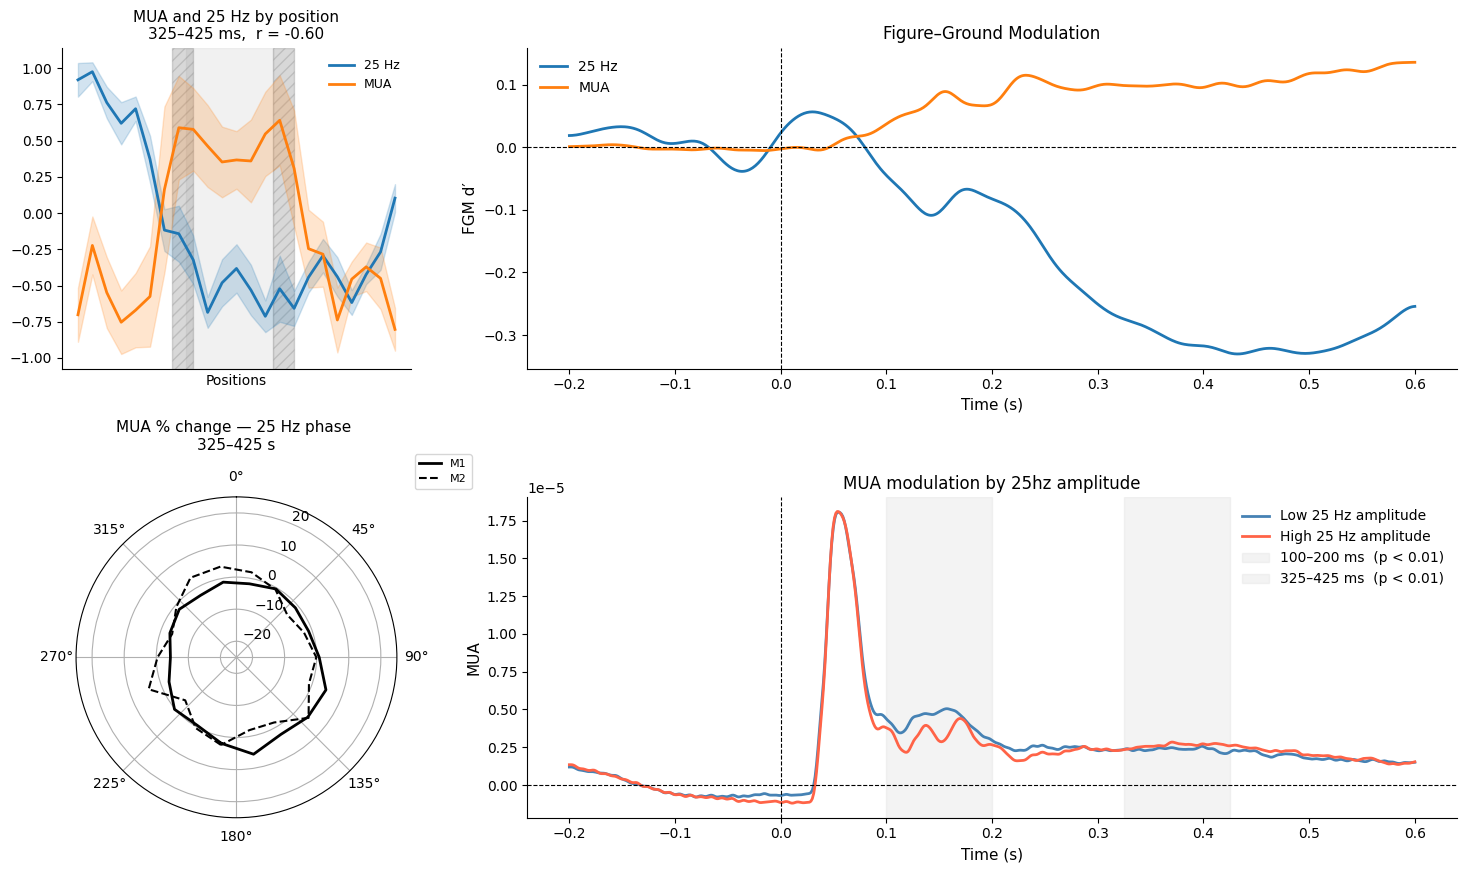

In [337]:
# =====================================================
# Plot for 25 Hz Supp
# =====================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 10))

outer = gridspec.GridSpec(
    2, 3,
    width_ratios=[1.2, 1.5, 1.3],
    height_ratios=[1, 1],
    wspace=0.3,
    hspace=0.4,
)

time_axis = np.linspace(-0.2, 0.6, X.shape[1])
positions_23 = list(range(23))


win_idx = 1
OFFSET = 2   

mean_8hz_m1  = results["mean_25hz"][win_idx]    # (23,)
mean_mua_m1  = results["mean_mua"][win_idx]    # (23,)

mean_8hz_m2_raw  = resultsM2["mean_25hz"][win_idx]   # (17,)
mean_mua_m2_raw  = resultsM2["mean_mua"][win_idx]   # (17,)

mean_8hz_m2  = np.full(23, np.nan)
mean_mua_m2  = np.full(23, np.nan)
mean_8hz_m2[OFFSET: OFFSET + len(mean_8hz_m2_raw)] = mean_8hz_m2_raw
mean_mua_m2[OFFSET: OFFSET + len(mean_mua_m2_raw)] = mean_mua_m2_raw

mean_8hz_both = np.nanmean([mean_8hz_m1, mean_8hz_m2], axis=0)
mean_mua_both = np.nanmean([mean_mua_m1, mean_mua_m2], axis=0)

std_8hz_both  = np.nanmean([results["std_25hz"][win_idx],
                             resultsM2["std_25hz"][win_idx]
                             if len(resultsM2["std_25hz"][win_idx]) == 23
                             else np.pad(resultsM2["std_25hz"][win_idx],
                                         (OFFSET, 23 - OFFSET - len(resultsM2["std_8hz"][win_idx])),
                                         constant_values=np.nan)],
                            axis=0)
std_mua_both  = np.nanmean([results["std_mua"][win_idx],
                             resultsM2["std_mua"][win_idx]
                             if len(resultsM2["std_mua"][win_idx]) == 23
                             else np.pad(resultsM2["std_mua"][win_idx],
                                         (OFFSET, 23 - OFFSET - len(resultsM2["std_mua"][win_idx])),
                                         constant_values=np.nan)],
                            axis=0)


from scipy.stats import pearsonr
valid = ~np.isnan(mean_8hz_both) & ~np.isnan(mean_mua_both)
r_both, p_both = pearsonr(mean_8hz_both[valid], mean_mua_both[valid])


both_valid_8hz  = ~np.isnan(mean_8hz_m1) & ~np.isnan(mean_8hz_m2)
both_valid_mua  = ~np.isnan(mean_mua_m1) & ~np.isnan(mean_mua_m2)

positions_23 = np.array(positions_23)

def plot_with_dashed_single(ax, positions, values, std, color, label):

    both_mask = ~np.isnan(mean_8hz_m1) & ~np.isnan(mean_8hz_m2)  #

    vals_solid = np.where(both_mask, values, np.nan)
    ax.plot(positions, vals_solid, color=color, lw=2, label=label)
    ax.fill_between(positions,
                    vals_solid - std, vals_solid + std,
                    color=color, alpha=0.2,
                    where=~np.isnan(vals_solid))
    vals_dash = np.where(~both_mask, values, np.nan)
    ax.plot(positions, vals_dash, color=color, lw=2, ls="--")
    ax.fill_between(positions,
                    vals_dash - std, vals_dash + std,
                    color=color, alpha=0.1,
                    where=~np.isnan(vals_dash))

ax_pos.axvspan(7.5, 13.5, color="lightgray", alpha=0.3)
for pos in [7, 14]:
    ax_pos.axvspan(pos - 0.5, pos + 1, color="gray", alpha=0.3, hatch="///")

plot_with_dashed_single(ax_pos, positions_23,
                        mean_8hz_both, std_8hz_both,
                        color="tab:blue", label="25 Hz")

plot_with_dashed_single(ax_pos, positions_23,
                        mean_mua_both, std_mua_both,
                        color="tab:orange", label="MUA")

ax_pos.set_title(f"MUA and 25 Hz by position\n325–425 ms,  r = {r_both:.2f}", fontsize=11)
ax_pos.set_xlabel("Positions", fontsize=10)
ax_pos.set_xticks([])
ax_pos.tick_params(axis='x', length=0)
ax_pos.spines['top'].set_visible(False)
ax_pos.spines['right'].set_visible(False)
ax_pos.legend(fontsize=9, frameon=False)
ax_pos.grid(False)
ax_pos.plot([], [], color="gray", lw=1.5, ls="--", label="single monkey")
ax_pos.legend(fontsize=9, frameon=False)

# =====================================================
# TOP LEFT
# =====================================================
ax_pos = fig.add_subplot(outer[0, 0])

ax_pos.axvspan(7.5, 13.5, color="lightgray", alpha=0.3)
for pos in [7, 14]:
    ax_pos.axvspan(pos - 0.5, pos + 1, color="gray", alpha=0.3, hatch="///")

ax_pos.plot(positions_23, mean_8hz_both, color="tab:blue",   lw=2, label="25 Hz")
ax_pos.fill_between(positions_23,
                    mean_8hz_both - std_8hz_both,
                    mean_8hz_both + std_8hz_both,
                    color="tab:blue", alpha=0.2)

ax_pos.plot(positions_23, mean_mua_both, color="tab:orange", lw=2, label="MUA")
ax_pos.fill_between(positions_23,
                    mean_mua_both - std_mua_both,
                    mean_mua_both + std_mua_both,
                    color="tab:orange", alpha=0.2)

ax_pos.set_title(f"MUA and 25 Hz by position\n325–425 ms,  r = {r_both:.2f}", fontsize=11)
ax_pos.set_xlabel("Positions", fontsize=10)
ax_pos.set_xticks([])
ax_pos.tick_params(axis='x', length=0)
ax_pos.spines['top'].set_visible(False)
ax_pos.spines['right'].set_visible(False)
ax_pos.legend(fontsize=9, frameon=False)
ax_pos.grid(False)

# =====================================================
# TOP RIGHT — FGM
# =====================================================
ax_fgm = fig.add_subplot(outer[0, 1:])

ax_fgm.plot(time_axis, fgm_both[-2],  label="25 Hz",  color="tab:blue", lw=2)
ax_fgm.plot(time_axis, fgm_both[-1], label="MUA",   color="tab:orange",    lw=2)
ax_fgm.axhline(0, color="k", lw=0.8, ls="--")
ax_fgm.axvline(0, color="k", lw=0.8, ls="--")
ax_fgm.set_xlabel("Time (s)", fontsize=11)
ax_fgm.set_ylabel("FGM d′", fontsize=11)
ax_fgm.set_title("Figure–Ground Modulation", fontsize=12)
ax_fgm.legend(fontsize=10, frameon=False)
ax_fgm.spines['top'].set_visible(False)
ax_fgm.spines['right'].set_visible(False)
ax_fgm.grid(False)

# =====================================================
# BOTTOM LEFT — Polar
# =====================================================
ax_pol = fig.add_subplot(outer[1, 0], projection='polar')

window_key = "0.33-0.42"

styles = [
    (phase_mua_results_low,    "M1",  "black",  "-",  2.0),
    (phase_mua_results_lowM2,  "M2",  "black",  "--", 1.5),
]

for store, label, color, ls, lw in styles:
    res           = store["8Hz"][window_key]
    phase_centers = res["phase_centers"]
    mua_binned    = res["mua_binned"]

    mean_val    = np.mean(mua_binned)
    mua_percent = (mua_binned - mean_val) / (mean_val + 1e-12) * 100

    phase_plot = np.append(phase_centers, phase_centers[0])
    mua_plot   = np.append(mua_percent,   mua_percent[0])

    ax_pol.plot(phase_plot, mua_plot, color=color, ls=ls, lw=lw, label=label)

ax_pol.set_theta_zero_location("N")
ax_pol.set_theta_direction(-1)
ax_pol.set_ylim(-25, 25)
ax_pol.set_title("MUA % change — 25 Hz phase \n325–425 s", fontsize=11, pad=15)
ax_pol.legend(fontsize=8, frameon=True,
              loc="upper right", bbox_to_anchor=(1.25, 1.15))
ax_pol.grid(True)

# =====================================================
# BOTTOM RIGHT — MUA conditioning
# =====================================================

ax_cond = fig.add_subplot(outer[1, 1:])

ax_cond.plot(time_axis, mual, label="Low 25 Hz amplitude",  color="steelblue", lw=2)
ax_cond.plot(time_axis, muah, label="High 25 Hz amplitude", color="tomato",    lw=2)

sig_str = f"p = {p_both:.3f}" if p_both > 0.01 else "p < 0.01"

ax_cond.axvspan(0.1, 0.2, color="lightgray", alpha=0.25, zorder=0,
                label=f"100–200 ms  ({sig_str})")

ax_cond.axvspan(0.325, 0.425, color="lightgray", alpha=0.25, zorder=0,
                label=f"325–425 ms  ({sig_str})")

ax_cond.axhline(0, color="k", lw=0.8, ls="--")
ax_cond.axvline(0, color="k", lw=0.8, ls="--")
ax_cond.set_xlabel("Time (s)", fontsize=11)
ax_cond.set_ylabel("MUA", fontsize=11)
ax_cond.set_title("MUA modulation by 25hz amplitude", fontsize=12)
ax_cond.legend(fontsize=10, frameon=False)
ax_cond.spines['top'].set_visible(False)
ax_cond.spines['right'].set_visible(False)
ax_cond.grid(False)

#plt.savefig("M1M2Figure_2_25hz.png", dpi=300, bbox_inches="tight")
plt.show()

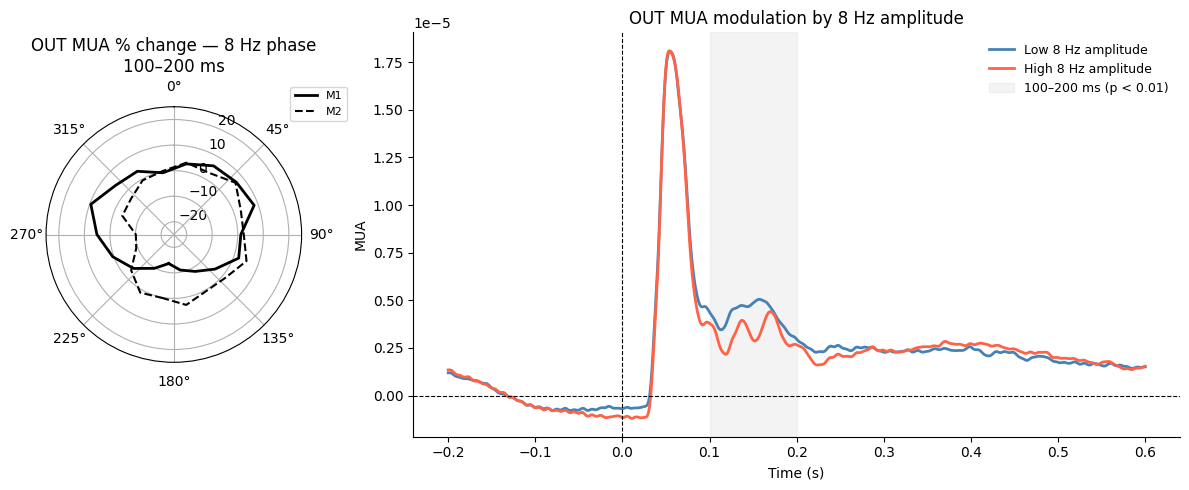

In [353]:
# =====================================================
# Plot for 8 Hz OUT Supp
# =====================================================

fig = plt.figure(figsize=(12, 5))

gs = fig.add_gridspec(1, 2, width_ratios=[1, 3])  #

ax_pol = fig.add_subplot(gs[0, 0], projection='polar')

window_key = "0.10-0.20"

styles = [
    (phase_mua_results,   "M1", "black", "-",  2.0),
    (phase_mua_resultsM2, "M2", "black", "--", 1.5),
]

for store, label, color, ls, lw in styles:
    res = store["8Hz"][window_key]
    phase_centers = res["phase_centers"]
    mua_binned    = res["mua_binned"]

    mean_val    = np.mean(mua_binned)
    mua_percent = (mua_binned - mean_val) / (mean_val + 1e-12) * 100

    phase_plot = np.append(phase_centers, phase_centers[0])
    mua_plot   = np.append(mua_percent,   mua_percent[0])

    ax_pol.plot(phase_plot, mua_plot, color=color, ls=ls, lw=lw, label=label)

ax_pol.set_theta_zero_location("N")
ax_pol.set_theta_direction(-1)
ax_pol.set_ylim(-25, 25)
ax_pol.set_title("OUT MUA % change — 8 Hz phase\n100–200 ms")
ax_pol.legend(fontsize=8, frameon=True,
              loc="upper right", bbox_to_anchor=(1.2, 1.1))

ax_cond = fig.add_subplot(gs[0, 1])

ax_cond.plot(time_axis, mual, label="Low 8 Hz amplitude",
             color="steelblue", lw=2)
ax_cond.plot(time_axis, muah, label="High 8 Hz amplitude",
             color="tomato", lw=2)

sig_str = f"p = {p_both:.3f}" if p_both > 0.01 else "p < 0.01"

ax_cond.axvspan(0.1, 0.2, color="lightgray", alpha=0.25,
                label=f"100–200 ms ({sig_str})")

ax_cond.axhline(0, color="k", lw=0.8, ls="--")
ax_cond.axvline(0, color="k", lw=0.8, ls="--")

ax_cond.set_xlabel("Time (s)")
ax_cond.set_ylabel("MUA")
ax_cond.set_title("OUT MUA modulation by 8 Hz amplitude")

ax_cond.legend(fontsize=9, frameon=False)
ax_cond.spines['top'].set_visible(False)
ax_cond.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("M1M2Figure_2_8hz_OUT.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# =====================================================
# Plot for FGM
# =====================================================

In [ ]:
fgm_both = np.load("M1M2fgm_both.pkl", allow_pickle=True).item()

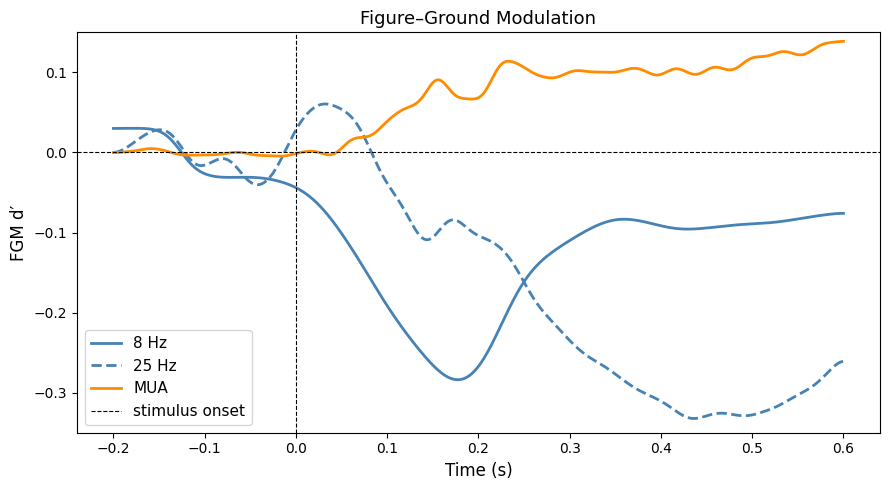

In [73]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(time_axis, fgm_both[3],  label="8 Hz",  color="steelblue", lw=2)
ax.plot(time_axis, fgm_both[-2], label="25 Hz", color="steelblue", lw=2, linestyle="--")
ax.plot(time_axis, fgm_both[-1], label="MUA",   color="darkorange",    lw=2)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.axvline(0, color="k", lw=0.8, ls="--", label="stimulus onset")
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("FGM d′", fontsize=12)
ax.set_title("Figure–Ground Modulation", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
ax.set_ylim(-0.35, 0.15)
plt.savefig("M1M2FGM_8_25.png", dpi=300, bbox_inches="tight")
plt.show()

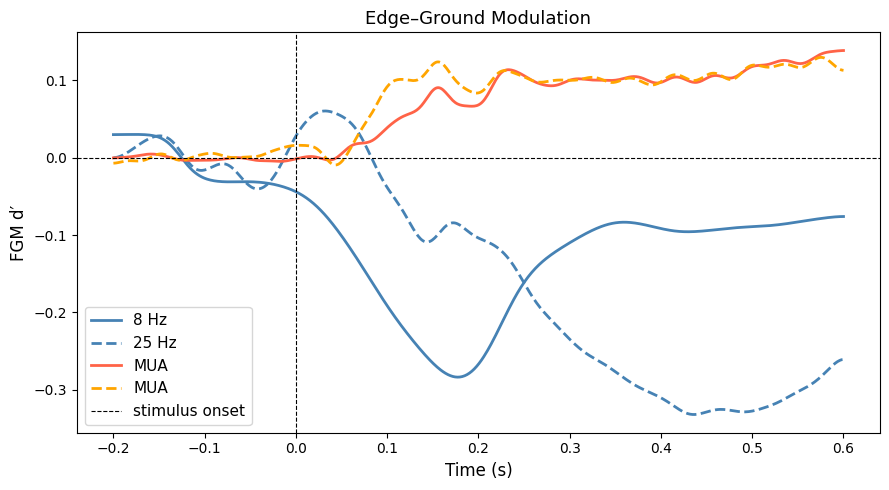

In [62]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(time_axis, fgm_both[3],  label="8 Hz",  color="steelblue", lw=2)
ax.plot(time_axis, fgm_both[-2],  label="25 Hz",  color="steelblue", lw=2, linestyle="--" )
ax.plot(time_axis, fgm_both[-1], label="MUA",   color="tomato",    lw=2)
ax.plot(time_axis, fgm_both_edge[-1], label="MUA", color="orange", lw=2, linestyle="--")

ax.axhline(0, color="k", lw=0.8, ls="--")
ax.axvline(0, color="k", lw=0.8, ls="--", label="stimulus onset")
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("FGM d′", fontsize=12)
ax.set_title("Edge–Ground Modulation", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()